In [6]:
import numpy as np
import pandas as pd
from sklearn import linear_model
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

In [7]:
df = pd.read_csv("/content/drive/MyDrive/insurance.csv")
df


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [8]:
df['sex'] = df['sex'].map({'male': 1, 'female': 0})
df['smoker'] = df['smoker'].map({'yes': 1, 'no': 0})
df['region'] = df['region'].map({'southwest': 0, 'southeast': 1, 'northwest': 2, 'northeast': 3})

In [9]:
X = df[['age','sex','bmi','children','smoker','region']]
y = df['charges']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [10]:
lr = linear_model.LinearRegression()
lr.fit(X_train,y_train)

LinearRegression()

In [11]:
y_pred = lr.predict(X_test)
print(f"R² Score: {r2_score(y_test, y_pred):.4f}")
print(f"RMSE:     {mean_squared_error(y_test, y_pred) ** 0.5:,.2f}")

R² Score: 0.7833
RMSE:     5,799.59


In [12]:
print(lr.predict([[21,0,24,0,0,1]]))

[967.76222111]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


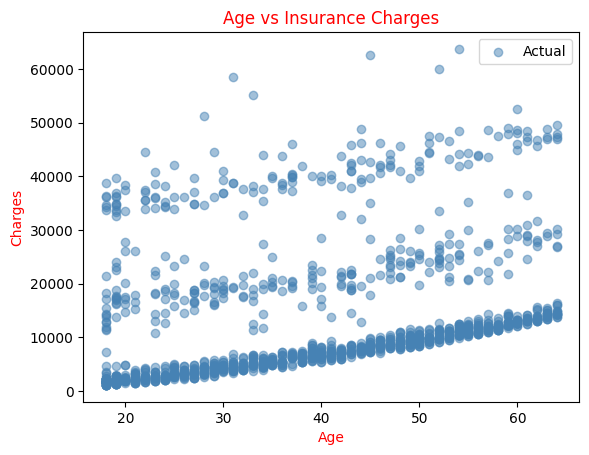

In [13]:

plt.scatter(df['age'], df['charges'], color='steelblue', alpha=0.5, label='Actual')
plt.xlabel("Age", color='red')
plt.ylabel("Charges", color='red')
plt.title("Age vs Insurance Charges", color='red')
plt.legend()
plt.show()

In [14]:
# Saving the trained model file
import pickle
with open('/content/drive/MyDrive/insurance.pkl', 'wb') as f:
  pickle.dump(lr,f)

In [15]:
# Loading the file
with open('/content/drive/MyDrive/insurance.pkl', 'rb') as f:
  lr2= pickle.load(f)

lr2.predict([[21,0,24,0,0,1]])

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([967.76222111])